In [1]:
from pathlib import Path

import numpy as np
import h5py
import json
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, Subset
from torchinfo import summary
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from improved_diffusion.models.vae import AbstractVAE

In [2]:
def vae_loss(x_hat, x, mu, logvar, beta=1.0, recon="mse"):
    if recon == "bce":
        rec = F.binary_cross_entropy_with_logits(x_hat, x, reduction="mean")
    else:
        rec = F.mse_loss(x_hat, x, reduction="mean")
    # KL(q(z|x) || N(0,I))
    kl = -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())
    return rec + beta * kl, rec, kl

In [3]:
DEVICE = torch.device(
    "mps"  if torch.backends.mps.is_available()  else
    "cuda" if torch.cuda.is_available()           else
    "cpu"
)

# 4 latent channels: forces the model to use each channel efficiently.
# For binary fiber microstructure, 4 channels cover density, orientation,
# scale, and residual — more than enough at 32×32 spatial resolution.
vae = AbstractVAE(
    in_channels=1,
    latent_channels=4,
    base_channels=32,
    channel_mult=(1, 2, 4, 4),
    dims=2,
    attn_ds=(4, 8),
    attn_heads=1,
    spatial_latent=True,
).to(DEVICE)

_dummy = torch.zeros(2, 1, 256, 256, device=DEVICE)
with torch.no_grad():
    _out, _mu, _lv, _z = vae(_dummy)
print(f"in:      {tuple(_dummy.shape)}")
print(f"latent:  {tuple(_z.shape)}")
print(f"out:     {tuple(_out.shape)}")
print(f"params:  {sum(p.numel() for p in vae.parameters()):,}")

in:      (2, 1, 256, 256)
latent:  (2, 4, 32, 32)
out:     (2, 1, 256, 256)
params:  2,488,265


In [4]:
from torch.utils.data import Dataset, DataLoader
import numpy as np
import h5py
import json 

class PatchDataset(Dataset):
    """
    HDF5-backed dataset with paired binary and grayscale patches.

    Returns (binary [1,H,W] float32 ∈ {0,1},
             gray   [1,H,W] float32 ∈ [0,1],
             phi    float32,
             source str)   ← originating filename, e.g. '245_00.h5'

    File handle opened lazily per worker — num_workers>0 safe.

    Parameters
    ----------
    h5_path       : path to the HDF5 file produced above
    class_filter  : optional list of class name strings to restrict to
    source_filter : optional list of source filenames to restrict to
    transform     : optional callable applied independently to each [1,H,W] tensor
    """

    def __init__(self, h5_path, class_filter=None, source_filter=None, transform=None):
        self.h5_path   = str(h5_path)
        self.transform = transform
        self._file     = None  # opened lazily per worker

        with h5py.File(self.h5_path, "r") as f:
            self.class_names  = json.loads(f.attrs["class_names"])
            self.source_files = json.loads(f.attrs["source_files"])
            class_ids = f["class_id"][:]
            sources   = f["source"][:].astype(str)  # str array

        mask = np.ones(len(class_ids), dtype=bool)
        if class_filter is not None:
            keep = {self.class_names.index(c) for c in class_filter}
            mask &= np.isin(class_ids, list(keep))
        if source_filter is not None:
            mask &= np.isin(sources, source_filter)
        self._indices = np.where(mask)[0]

    def __len__(self):
        return len(self._indices)

    def __getitem__(self, i):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r")
        idx = int(self._indices[i])

        binary = torch.from_numpy(
            self._file["patches"][idx].astype(np.float32)
        ).unsqueeze(0)                                           # [1, H, W] ∈ {0,1}
        gray = torch.from_numpy(
            self._file["images"][idx].astype(np.float32) / 255.0
        ).unsqueeze(0)                                           # [1, H, W] ∈ [0,1]
        phi    = torch.tensor(float(self._file["phi"][idx]))
        s      = self._file["source"][idx]
        source = s.decode() if isinstance(s, bytes) else str(s)  # h5py 2/3 compat

        if self.transform is not None:
            binary = self.transform(binary)
            gray   = self.transform(gray)
        return binary, gray, phi, source

In [5]:
file_path = Path("../data/patches_vae.h5")

# ── sanity check ──────────────────────────────────────────────────────────────
ds     = PatchDataset(file_path)
loader = DataLoader(ds, batch_size=16, shuffle=True, num_workers=0)
xb, gb, pb, sb = next(iter(loader))
print(f"\nSanity check  (num_workers=0):")
print(f"  binary shape : {tuple(xb.shape)}  unique={xb.unique().tolist()}")
print(f"  gray   shape : {tuple(gb.shape)}  range=[{gb.min():.3f}, {gb.max():.3f}]")
print(f"  phi range    : [{pb.min():.4f}, {pb.max():.4f}]")
print(f"  sources      : {sb}")


Sanity check  (num_workers=0):
  binary shape : (16, 1, 512, 512)  unique=[0.0, 1.0]
  gray   shape : (16, 1, 512, 512)  range=[0.408, 1.000]
  phi range    : [0.6145, 0.7662]
  sources      : ('245_02.h5', '245_02.h5', '245_02.h5', '245_00.h5', '245_02.h5', '245_00.h5', '245_01.h5', '245_01.h5', '245_01.h5', '245_02.h5', '245_01.h5', '245_01.h5', '245_02.h5', '245_01.h5', '245_02.h5', '245_01.h5')


In [6]:
# ── overfit subset: 200 patches, downscale 512→256 ─────────────────────────
N_OVERFIT  = 2000
BATCH_SIZE = 4

overfit_subset = Subset(ds, list(range(N_OVERFIT)))

print(f"cratd dataset with {len(overfit_subset)}")
def _collate_downscale(batch):
    binary_list, gray_list, phi_list, _ = zip(*batch)
    x = torch.stack(binary_list)                     # [B, 1, 512, 512] ∈ {0,1}
    x = F.avg_pool2d(x, kernel_size=2, stride=2)    # [B, 1, 256, 256]
    x = (x > 0.5).float() * 2.0 - 1.0              # re-threshold → {-1, 1}
    phi = torch.stack(phi_list)                      # [B] fiber volume fraction
    return x, phi

overfit_loader = DataLoader(
    overfit_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=_collate_downscale,
    drop_last=False,
)

_xb, _phi = next(iter(overfit_loader))
print(f"x:   {tuple(_xb.shape)}   values: {_xb.unique().tolist()}")
print(f"phi: {tuple(_phi.shape)}  range:  [{_phi.min():.3f}, {_phi.max():.3f}]")

def _cycle(dl):
    while True:
        yield from dl

data_iter = _cycle(overfit_loader)

cratd dataset with 2000
x:   (4, 1, 256, 256)   values: [-1.0, 1.0]
phi: (4,)  range:  [0.689, 0.720]


In [11]:
TOTAL_STEPS       = 3000
LR                = 1e-3
GRAD_CLIP         = 1.0
LOG_INTERVAL      = 50

# Target: σ ∈ [0.5, 0.9] after training.
# β=1e-3 → σ collapses to ~0.01 (encoder ignores stochasticity, prior gap).
# β=0.5  → μ collapses to 0 (KL dominates, blurry latent).
# β=0.05 is the middle ground: KL is ~10–20% of total loss, enough to
# push σ toward 1 without crushing reconstruction quality.
BETA_MAX          = 9e-2
BETA_WARMUP_STEPS = 1000   # reconstruction converges first, then KL kicks in

opt = AdamW(vae.parameters(), lr=LR, weight_decay=1e-5)

def beta_schedule(step: int) -> float:
    if BETA_WARMUP_STEPS <= 0:
        return BETA_MAX
    return BETA_MAX * min(1.0, step / BETA_WARMUP_STEPS)

In [12]:
history = {"step": [], "loss": [], "recon": [], "kl": [], "beta": [], "sigma_mean": []}

vae.train()
pbar = tqdm(range(TOTAL_STEPS), leave=True)

for step in pbar:
    x, _phi = next(data_iter)
    x = x.to(DEVICE)
    beta = beta_schedule(step)

    opt.zero_grad(set_to_none=True)
    x_hat, mu, logvar, z = vae(x)
    loss, rec, kl = vae_loss(x_hat, x, mu, logvar, beta=beta)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(vae.parameters(), GRAD_CLIP)
    opt.step()

    if step % LOG_INTERVAL == 0:
        sigma_mean = logvar.mul(0.5).exp().mean().item()
        history["step"].append(step)
        history["loss"].append(loss.item())
        history["recon"].append(rec.item())
        history["kl"].append(kl.item())
        history["beta"].append(beta)
        history["sigma_mean"].append(sigma_mean)
        pbar.set_postfix(
            rec=f"{rec.item():.4f}",
            kl=f"{kl.item():.3f}",
            sig=f"{sigma_mean:.3f}",
            beta=f"{beta:.1e}",
        )

print("done.")

  0%|          | 0/3000 [00:00<?, ?it/s]

done.


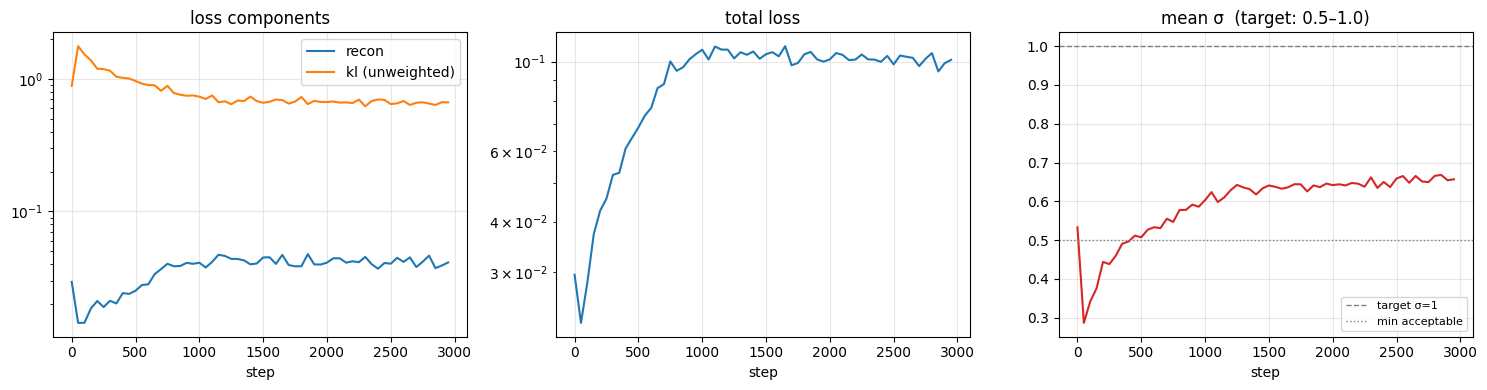

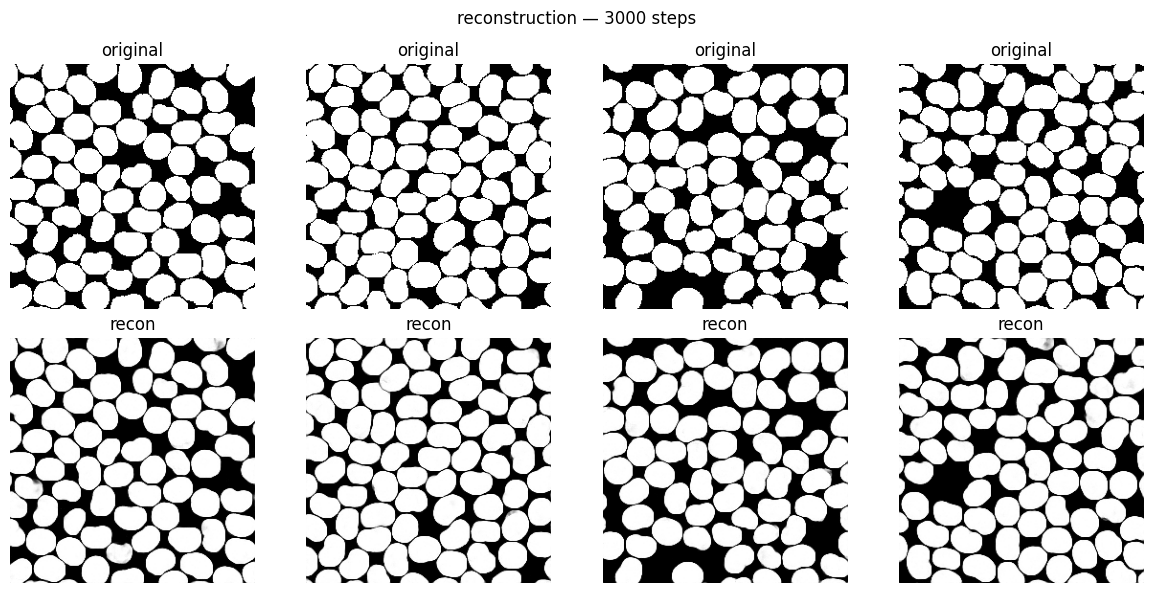

AbstractVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ResBlock(
      (net): Sequential(
        (0): GroupNorm32(32, 32, eps=1e-05, affine=True)
        (1): SiLU()
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): GroupNorm32(32, 32, eps=1e-05, affine=True)
        (4): SiLU()
        (5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (2): Downsample(
      (op): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    )
    (3): ResBlock(
      (net): Sequential(
        (0): GroupNorm32(32, 64, eps=1e-05, affine=True)
        (1): SiLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): GroupNorm32(32, 64, eps=1e-05, affine=True)
        (4): SiLU()
        (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (4): Downsample(
      (op): Conv2d(64,

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
s = history["step"]
axes[0].plot(s, history["recon"], label="recon")
axes[0].plot(s, history["kl"],   label="kl (unweighted)")
axes[0].set_yscale("log")
axes[0].legend(); axes[0].set_title("loss components"); axes[0].grid(alpha=0.3)
axes[1].plot(s, history["loss"]); axes[1].set_yscale("log")
axes[1].set_title("total loss"); axes[1].grid(alpha=0.3)
axes[2].plot(s, history["sigma_mean"], color="tab:red")
axes[2].axhline(1.0, ls="--", color="grey", lw=1, label="target σ=1")
axes[2].axhline(0.5, ls=":",  color="grey", lw=1, label="min acceptable")
axes[2].legend(fontsize=8); axes[2].set_title("mean σ  (target: 0.5–1.0)")
axes[2].grid(alpha=0.3)
for ax in axes:
    ax.set_xlabel("step")
plt.tight_layout(); plt.show()

# ── reconstructions ────────────────────────────────────────────────────────
vae.eval()
with torch.no_grad():
    x_fixed, _phi = next(iter(overfit_loader))
    x_fixed = x_fixed.to(DEVICE)
    x_hat, *_ = vae(x_fixed)

n = min(4, x_fixed.shape[0])
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
for i in range(n):
    axes[0, i].imshow(x_fixed[i, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
    axes[0, i].set_title("original"); axes[0, i].axis("off")
    axes[1, i].imshow(x_hat[i, 0].cpu(),  cmap="gray", vmin=-1, vmax=1)
    axes[1, i].set_title("recon"); axes[1, i].axis("off")
plt.suptitle(f"reconstruction — {TOTAL_STEPS} steps")
plt.tight_layout(); plt.show()
vae.train()

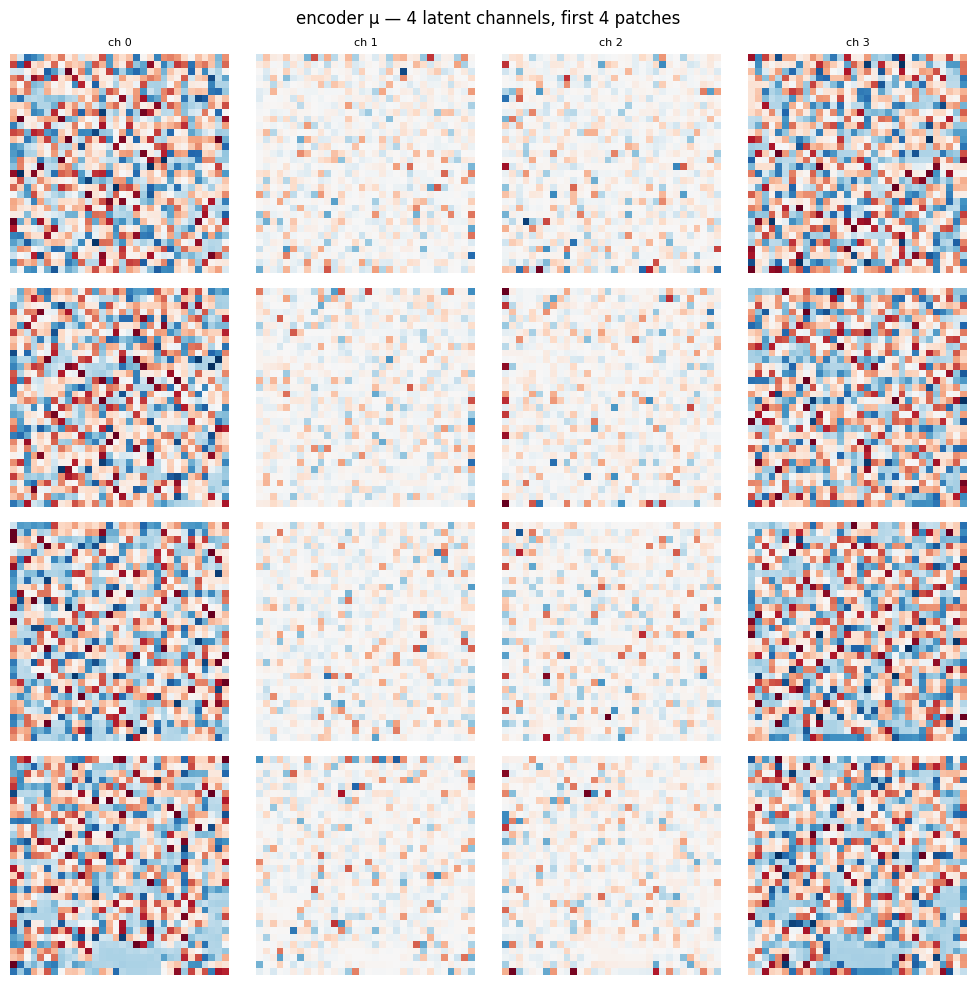

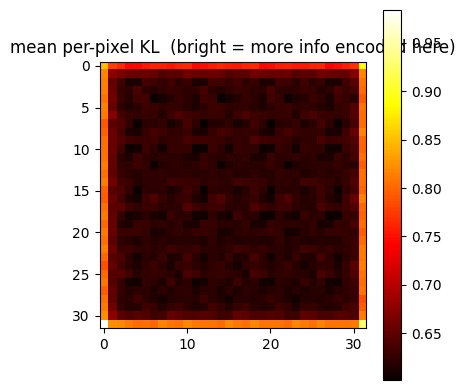

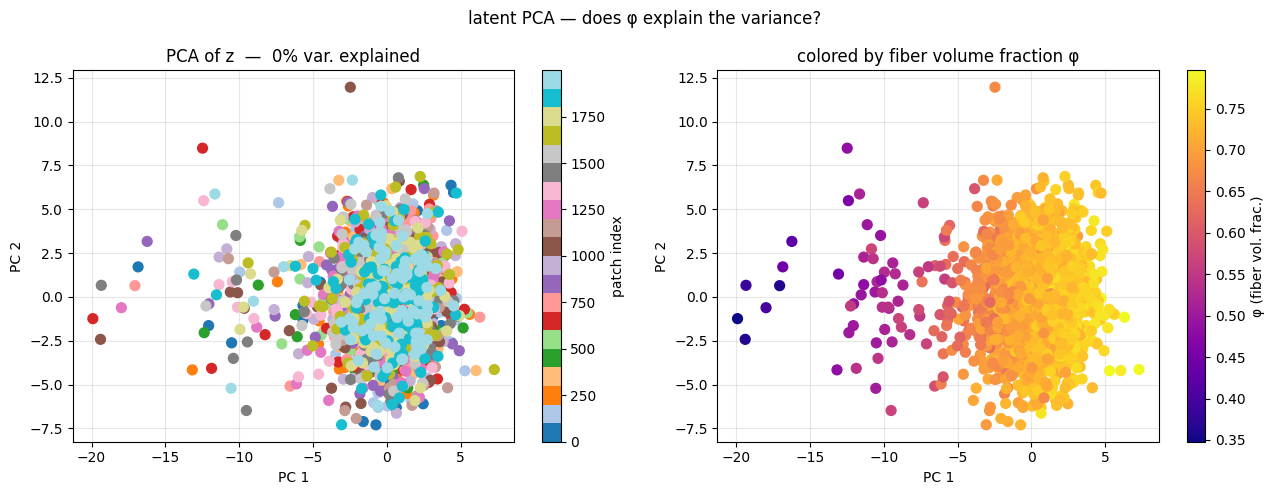

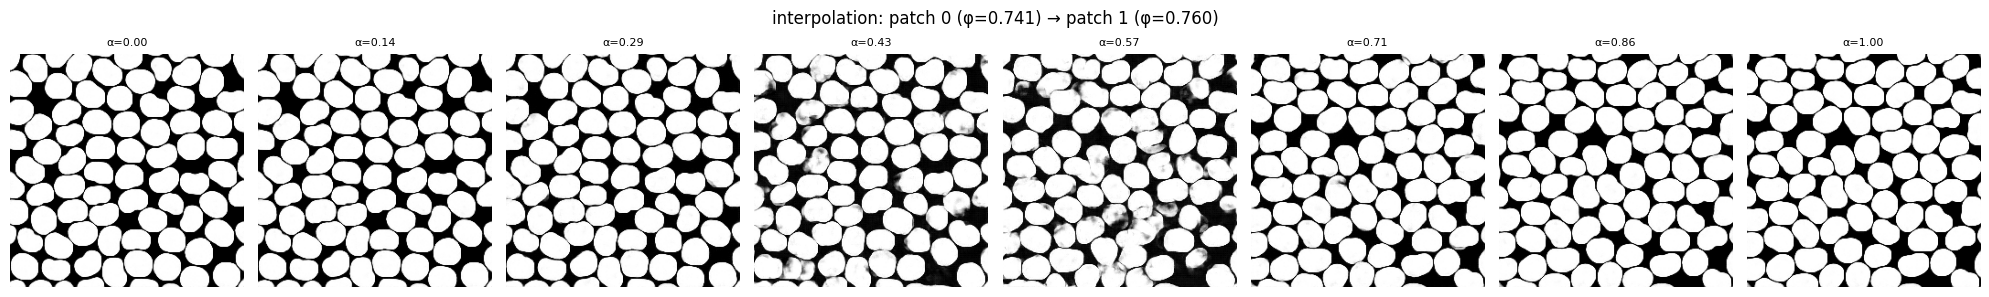

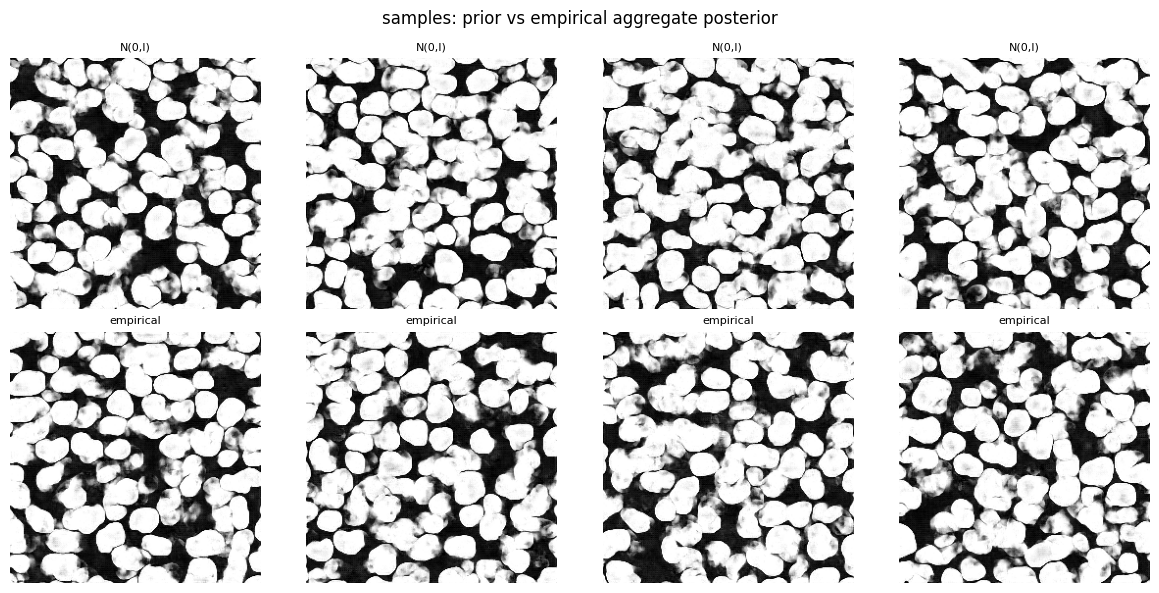

μ range:   [-3.70, 4.55]  (near 0 = well aligned)
σ range:   [0.03, 1.24]  (near 1 = well aligned)
mean |μ|:  0.471
φ range:   [0.348, 0.796]


In [14]:
@torch.no_grad()
def explore_latent(loader=overfit_loader):
    vae.eval()

    # ── encode in batches, accumulate on CPU ──────────────────────────────
    all_mu, all_logvar, all_x, all_phi = [], [], [], []
    for x, phi in loader:
        mu_b, logvar_b = vae.encode(x.to(DEVICE))
        all_mu.append(mu_b.cpu())
        all_logvar.append(logvar_b.cpu())
        all_x.append(x)
        all_phi.append(phi)

    mu     = torch.cat(all_mu)
    logvar = torch.cat(all_logvar)
    x_all  = torch.cat(all_x)
    phi    = torch.cat(all_phi).numpy()   # [N]  fiber volume fraction
    z      = vae.reparameterize(mu, logvar)
    N      = mu.shape[0]
    C_lat  = mu.shape[1]

    # ── 1. per-channel μ maps ─────────────────────────────────────────────
    n_show = min(4, N)
    fig, axes = plt.subplots(n_show, C_lat, figsize=(2.5 * C_lat, 2.5 * n_show))
    for row in range(n_show):
        for col in range(C_lat):
            axes[row, col].imshow(mu[row, col], cmap="RdBu_r", vmin=-2, vmax=2)
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(f"ch {col}", fontsize=8)
        axes[row, 0].set_ylabel(f"patch {row}", fontsize=8)
    plt.suptitle(f"encoder μ — {C_lat} latent channels, first {n_show} patches")
    plt.tight_layout(); plt.show()

    # ── 2. per-pixel KL heatmap ───────────────────────────────────────────
    kl_map  = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl_mean = kl_map.mean(dim=(0, 1))

    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(kl_mean, cmap="hot")
    plt.colorbar(im, ax=ax)
    ax.set_title("mean per-pixel KL  (bright = more info encoded here)")
    plt.tight_layout(); plt.show()

    # ── 3. PCA — patch index + fiber volume fraction side by side ─────────
    z_flat = z.reshape(N, -1).float()
    z_c    = z_flat - z_flat.mean(0)
    _, S, Vh = torch.linalg.svd(z_c, full_matrices=False)
    z_2d    = (z_c @ Vh[:2].T).numpy()
    var_exp = (S[:2].pow(2) / S.pow(2).sum()).sum().item()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # left: patch index
    sc0 = axes[0].scatter(z_2d[:, 0], z_2d[:, 1], c=np.arange(N),
                          cmap="tab20", s=50, zorder=2)
    plt.colorbar(sc0, ax=axes[0], label="patch index")
    axes[0].set_title(f"PCA of z  —  {var_exp:.0%} var. explained")

    # right: fiber volume fraction
    sc1 = axes[1].scatter(z_2d[:, 0], z_2d[:, 1], c=phi,
                          cmap="plasma", s=50, zorder=2)
    cb = plt.colorbar(sc1, ax=axes[1], label="φ (fiber vol. frac.)")
    axes[1].set_title("colored by fiber volume fraction φ")

    for ax in axes:
        ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.grid(alpha=0.3)
    plt.suptitle("latent PCA — does φ explain the variance?")
    plt.tight_layout(); plt.show()

    # ── 4. latent interpolation patch 0 → patch 1 ────────────────────────
    n_steps = 8
    alphas  = torch.linspace(0, 1, n_steps)
    z_lerp  = torch.stack([(1 - a) * mu[0] + a * mu[1] for a in alphas]).to(DEVICE)
    x_lerp  = vae.decode(z_lerp).cpu()

    fig, axes = plt.subplots(1, n_steps, figsize=(2.5 * n_steps, 3))
    for i, ax in enumerate(axes):
        ax.imshow(x_lerp[i, 0], cmap="gray", vmin=-1, vmax=1)
        ax.set_title(f"α={alphas[i]:.2f}", fontsize=8); ax.axis("off")
    plt.suptitle(f"interpolation: patch 0 (φ={phi[0]:.3f}) → patch 1 (φ={phi[1]:.3f})")
    plt.tight_layout(); plt.show()

    # ── 5. prior N(0,I) vs empirical aggregate posterior ─────────────────
    mu_agg  = mu.mean(0, keepdim=True).to(DEVICE)
    std_agg = mu.std(0, keepdim=True).clamp_min(0.05).to(DEVICE)

    z_prior = torch.randn(4, *mu.shape[1:], device=DEVICE)
    z_emp   = mu_agg + std_agg * torch.randn(4, *mu.shape[1:], device=DEVICE)

    x_prior = vae.decode(z_prior).cpu()
    x_emp   = vae.decode(z_emp).cpu()

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i in range(4):
        axes[0, i].imshow(x_prior[i, 0], cmap="gray", vmin=-1, vmax=1)
        axes[0, i].set_title("N(0,I)", fontsize=8); axes[0, i].axis("off")
        axes[1, i].imshow(x_emp[i, 0],   cmap="gray", vmin=-1, vmax=1)
        axes[1, i].set_title("empirical", fontsize=8); axes[1, i].axis("off")
    axes[0, 0].set_ylabel("prior N(0,I)\n(needs high β)", fontsize=8)
    axes[1, 0].set_ylabel("empirical agg.\n(works now)", fontsize=8)
    plt.suptitle("samples: prior vs empirical aggregate posterior")
    plt.tight_layout(); plt.show()

    # ── posterior alignment stats ─────────────────────────────────────────
    print(f"μ range:   [{mu.min():.2f}, {mu.max():.2f}]  (near 0 = well aligned)")
    print(f"σ range:   [{logvar.mul(0.5).exp().min():.2f}, {logvar.mul(0.5).exp().max():.2f}]  (near 1 = well aligned)")
    print(f"mean |μ|:  {mu.abs().mean():.3f}")
    print(f"φ range:   [{phi.min():.3f}, {phi.max():.3f}]")

    vae.train()

explore_latent()

In [ ]:
@torch.no_grad()
def latent_physical_alignment(loader=overfit_loader):
    """
    Quantifies how well the VAE latent space aligns with two physical metrics:
      - phi:  fiber volume fraction (label from HDF5)
      - diam: mean fiber diameter estimated via distance transform (EDT radius x2)

    PCA is run on the spatially-pooled latent [N, C_lat] so each PC corresponds
    to a direction in channel space. Spearman rho is rank-based, bounded [-1, 1].
    |rho| > 0.5 suggests the latent genuinely organises along that metric.
    """
    from scipy.ndimage import distance_transform_edt

    vae.eval()

    all_mu, all_phi, all_phi_actual, all_diam = [], [], [], []
    for x, phi in loader:
        mu_b, _ = vae.encode(x.to(DEVICE))
        all_mu.append(mu_b.cpu())
        all_phi.append(phi)

        phi_actual = (x > 0).float().mean(dim=(1, 2, 3))
        all_phi_actual.append(phi_actual)

        # mean fiber diameter: EDT gives radius at each fiber pixel; *2 -> diameter
        x_np = (x[:, 0].numpy() > 0).astype(np.uint8)   # [B, H, W] binary
        diam_batch = []
        for b in range(x_np.shape[0]):
            dt   = distance_transform_edt(x_np[b])
            mask = dt > 0
            diam_batch.append(2.0 * float(dt[mask].mean()) if mask.any() else 0.0)
        all_diam.append(torch.tensor(diam_batch, dtype=torch.float32))

    mu         = torch.cat(all_mu)               # [N, C_lat, H', W']
    phi        = torch.cat(all_phi).numpy()
    phi_actual = torch.cat(all_phi_actual).numpy()
    diam       = torch.cat(all_diam).numpy()      # [N]  mean fiber diameter (px)
    N, C_lat   = mu.shape[0], mu.shape[1]

    # global avg pool -> [N, C_lat]
    mu_pooled = mu.mean(dim=(-2, -1))

    # PCA on [N, C_lat]
    z_c = mu_pooled - mu_pooled.mean(0)
    _, S, Vh = torch.linalg.svd(z_c, full_matrices=False)
    pcs       = (z_c @ Vh.T).numpy()             # [N, C_lat]
    var_ratio = (S.pow(2) / S.pow(2).sum()).numpy()

    # Spearman rho
    def spearman(a, b):
        ra = np.argsort(np.argsort(a)).astype(float)
        rb = np.argsort(np.argsort(b)).astype(float)
        ra -= ra.mean(); rb -= rb.mean()
        return float(np.dot(ra, rb) / (np.linalg.norm(ra) * np.linalg.norm(rb) + 1e-12))

    rhos_phi  = np.array([spearman(pcs[:, i], phi)  for i in range(C_lat)])
    rhos_diam = np.array([spearman(pcs[:, i], diam) for i in range(C_lat)])
    best_phi  = int(np.argmax(np.abs(rhos_phi)))
    best_diam = int(np.argmax(np.abs(rhos_diam)))

    # grouped bar chart: rho(phi) and rho(diam) per PC
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    x_pos = np.arange(C_lat)
    width = 0.35
    b1 = axes[0].bar(x_pos - width/2, rhos_phi,  width, label="rho(phi)",  color="tab:blue")
    b2 = axes[0].bar(x_pos + width/2, rhos_diam, width, label="rho(diam)", color="tab:orange")
    axes[0].bar_label(b1, labels=[f"{r:+.2f}" for r in rhos_phi],  fontsize=7, padding=2)
    axes[0].bar_label(b2, labels=[f"{r:+.2f}" for r in rhos_diam], fontsize=7, padding=2)
    axes[0].axhline( 0.5, ls="--", color="grey", lw=1)
    axes[0].axhline(-0.5, ls="--", color="grey", lw=1)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels([f"PC{i}\n({v:.0%} var)" for i, v in enumerate(var_ratio)])
    axes[0].set_ylabel("Spearman rho")
    axes[0].set_title("Latent PCs vs physical metrics\n(|rho| > 0.5 = strong)")
    axes[0].legend()

    # best phi-PC scatter, colored by diameter to show cross-correlation
    pc_best  = pcs[:, best_phi]
    m, b_    = np.polyfit(phi, pc_best, 1)
    phi_line = np.linspace(phi.min(), phi.max(), 100)

    sc = axes[1].scatter(phi, pc_best, c=diam, cmap="viridis", s=40, zorder=2)
    plt.colorbar(sc, ax=axes[1], label="mean fiber diam. (px)")
    axes[1].plot(phi_line, m * phi_line + b_, color="crimson", lw=1.5,
                 label=f"rho(phi) = {rhos_phi[best_phi]:+.3f}")
    axes[1].set_xlabel("phi (fiber vol. frac.)")
    axes[1].set_ylabel(f"PC {best_phi}  ({var_ratio[best_phi]:.0%} var)")
    axes[1].set_title("Best phi-PC vs phi, colored by fiber diameter")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle("VAE latent alignment: fiber volume fraction and diameter")
    plt.tight_layout(); plt.show()

    # summary table
    phi_err = np.abs(phi - phi_actual).mean()
    print(f"phi label vs pixel mean  -- MAE: {phi_err:.4f}")
    print(f"diam range: [{diam.min():.1f}, {diam.max():.1f}] px   mean = {diam.mean():.1f} px")
    print()
    print(f"{'PC':>4}  {'var':>7}  {'rho(phi)':>10}  {'rho(diam)':>10}")
    print("-" * 42)
    for i in range(C_lat):
        tag_phi  = " <phi"  if i == best_phi  else ""
        tag_diam = " <diam" if i == best_diam else ""
        print(f"{i:>4}  {var_ratio[i]:>6.1%}  {rhos_phi[i]:>+10.4f}{tag_phi:<6}  {rhos_diam[i]:>+10.4f}{tag_diam}")

    vae.train()

latent_physical_alignment()